# **Tập dữ liệu**

In [2]:
!pip install -q datasets huggingface_hub

In [3]:
!pip install -q ImageHash

In [5]:
from google.colab import drive

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Sửa save_path tùy theo vị trí lưu dataset mong muốn
save_path = "/content/drive/MyDrive/intel_images"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Dataset vào Google Drive nếu chưa có sẵn
*bỏ qua phần này nếu đã tải*

Lưu ý có thế mất khoảng 2 tiếng để download hết bằng code này.

Download nhanh qua link Drive bên dưới: https://drive.google.com/drive/folders/1_Lsyg5JcQHV8w2sPigDQqSUlOBQ0Jp8a?usp=sharing

In [ ]:
from google.colab import userdata
import os

# Trên Google Colab có thể lấy Access Token từ https://huggingface.co/settings/tokens và lưu với tên HF_TOKEN trong tab "Secrets"
os.environ["HF_TOKEN"] = userdata.get('HF_TOKEN')

In [ ]:
from huggingface_hub import notebook_login

# Nếu không có sẵn HF_TOKEN trong env thì có thể nhập vào sau khi chạy dòng bên dưới
notebook_login()

KeyboardInterrupt: 

In [ ]:
# Create a specific folder for the dataset
save_path = "/content/drive/MyDrive/intel_images"
os.makedirs(save_path, exist_ok=True)

In [ ]:
from datasets import load_dataset
from PIL import Image

ds = load_dataset("sfarrukhm/intel-image-classification", streaming=True)

splits = ['train', 'test']

for split in splits:
    print(f"Downloading {split} split...")
    for i, example in enumerate(ds[split]):
        label = ds[split].features['label'].int2str(example['label'])

        # Create directory: /content/drive/MyDrive/intel_images/train/buildings/
        folder = os.path.join(save_path, split, label)
        os.makedirs(folder, exist_ok=True)

        # Save the image
        img = example['image']
        img.save(f"{folder}/{i}.jpg")

        if i % 500 == 0:
            print(f"Saved {i} images for {split}...")

## Load Data từ Drive nếu đã có sẵn

In [6]:
from datasets import load_dataset

ds = load_dataset("imagefolder", data_dir=save_path)

Resolving data files:   0%|          | 0/14034 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/2958 [00:00<?, ?it/s]

In [7]:
print(ds)

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 14034
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 2958
    })
})


## Chuẩn bị dữ liệu

Mặc dù tập dữ liệu đã được chia sẵn thành train và test set, nhưng do yêu cầu của bài tập tập trung vào bước tiền xử lý và số lượng ảnh trong dataset khá lớn khiến thời gian tính toán bị kéo dài. Vì vậy, trong phạm vi bài tập này, nhóm chỉ chọn ngẫu nhiên 5.000 ảnh từ tập train để tiến hành xử lý và đánh giá.

In [8]:
# Define constants
N = 5000
H = 150
W = 150
SEED = 42

In [9]:
dataset = ds['train'].shuffle(seed=SEED).select(range(N))
len(dataset)

5000

In [10]:
dataset[0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=150x150>,
 'label': 4}

In [11]:
import numpy as np
from tqdm import tqdm
from PIL import Image

image_list = []
label_list = []
original_size = (150, 150)

for item in tqdm(dataset):
  pil_img = item['image'].convert("RGB")
  img_resized_pil = pil_img.resize(original_size, Image.LANCZOS)
  img_resized_np = np.array(img_resized_pil)

  image_list.append(img_resized_np)
  label_list.append(item['label'])

100%|██████████| 5000/5000 [00:48<00:00, 103.02it/s]


In [12]:
images = np.array(image_list)
labels = np.array(label_list)

In [13]:
print(f"\nShape of images: {images.shape}") # (5000, 150, 150, 3) ~ (N, H, W, 3)
print(f"Shape of label: {labels.shape}")   # (5000,)


Shape of images: (5000, 150, 150, 3)
Shape of label: (5000,)


In [14]:
print(label_list)

[4, 4, 4, 2, 4, 1, 2, 3, 2, 2, 3, 5, 4, 1, 3, 4, 2, 0, 5, 0, 0, 2, 2, 0, 5, 5, 4, 3, 3, 3, 5, 1, 3, 2, 4, 2, 4, 5, 1, 2, 0, 5, 2, 4, 4, 0, 4, 3, 4, 0, 3, 1, 0, 0, 4, 3, 1, 2, 0, 5, 1, 0, 2, 4, 3, 0, 0, 1, 1, 5, 4, 1, 0, 2, 5, 1, 4, 4, 3, 3, 2, 0, 2, 1, 3, 2, 4, 1, 2, 3, 5, 0, 3, 2, 2, 0, 2, 1, 5, 1, 0, 5, 0, 4, 5, 0, 0, 1, 5, 5, 1, 4, 3, 0, 5, 5, 4, 1, 1, 3, 2, 5, 5, 0, 5, 3, 4, 0, 0, 5, 4, 2, 5, 3, 1, 5, 3, 3, 2, 3, 3, 4, 0, 3, 4, 5, 0, 1, 2, 3, 2, 5, 4, 1, 5, 3, 1, 1, 3, 5, 2, 4, 1, 3, 1, 1, 3, 3, 0, 2, 3, 2, 2, 3, 5, 2, 3, 3, 0, 4, 1, 2, 0, 5, 2, 4, 3, 5, 2, 4, 0, 5, 4, 5, 4, 5, 0, 3, 0, 5, 4, 1, 0, 3, 1, 5, 2, 0, 3, 4, 2, 0, 4, 3, 3, 1, 0, 2, 2, 3, 4, 5, 0, 3, 1, 5, 1, 3, 3, 3, 1, 3, 0, 5, 0, 1, 4, 0, 0, 0, 5, 5, 3, 5, 5, 5, 1, 1, 4, 2, 2, 5, 4, 5, 2, 3, 4, 2, 1, 0, 1, 1, 1, 2, 0, 5, 2, 4, 0, 5, 4, 2, 5, 4, 4, 5, 1, 1, 3, 1, 1, 2, 3, 0, 2, 3, 0, 1, 4, 3, 1, 1, 3, 2, 4, 1, 3, 5, 2, 4, 3, 5, 2, 3, 4, 3, 3, 0, 1, 2, 2, 0, 5, 3, 3, 4, 1, 0, 3, 5, 1, 2, 1, 4, 2, 5, 2, 2, 2, 2, 5, 5, 2, 

---
# **Phân tích thống kê tập dữ liệu**

## Tính và trực quan hóa phân phối giá trị pixel trên toàn tập (histogram, KDE) theo từng kênh màu.


In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

Kích thước channel red: 112500000
Sample 1000000 pixel cho channel RED.
Kích thước channel green: 112500000
Sample 1000000 pixel cho channel GREEN.
Kích thước channel blue: 112500000
Sample 1000000 pixel cho channel BLUE.


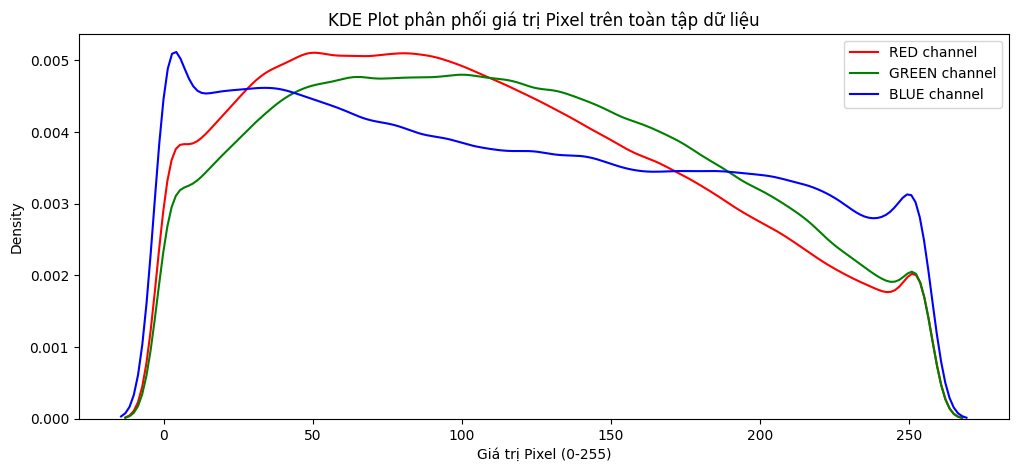

In [16]:
def plot_pixel_dist_kde(image_set, sample_size=None):
    colors = ('red', 'green', 'blue')
    plt.figure(figsize=(12, 5))

    for i, color in enumerate(colors):
        # dùng ravel để lấy mảng 1D array của từng kênh màu (5000 x 150 x 150, )
        all_channel_vals = image_set[:, :, :, i].ravel()
        total_pixels = len(all_channel_vals)
        print(f"Kích thước channel {color}: {total_pixels}")

        if sample_size and total_pixels > sample_size: # Downsampling khi kích thước mảng quá lớn
            step = total_pixels // sample_size
            channel_vals = all_channel_vals[::step][:sample_size]
            print(f"Sample {len(channel_vals)} pixel cho channel {color.upper()}.")
        else:
            channel_vals = all_channel_vals
            print(f"Dùng tất cả {total_pixels} pixels cho channel {color.upper()}.")

        sns.kdeplot(channel_vals, color=color, label=f'{color.upper()} channel')

    plt.title("KDE Plot phân phối giá trị Pixel trên toàn tập dữ liệu")
    plt.xlabel("Giá trị Pixel (0-255)")
    plt.legend()
    plt.show()

plot_pixel_dist_kde(image_set=images, sample_size = 1000000)


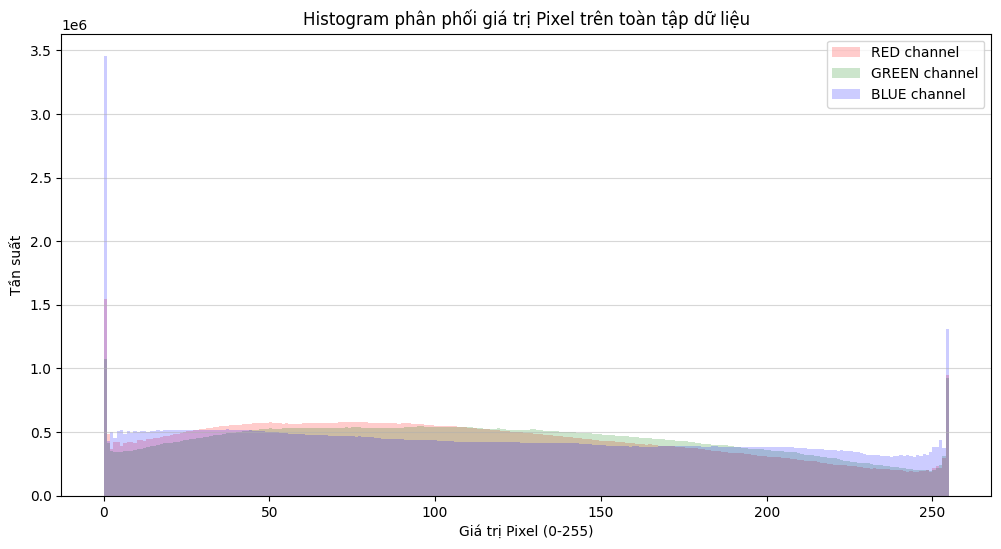

In [17]:
def plot_pixel_dist_histogram(image_set):
    colors = ('red', 'green', 'blue')
    plt.figure(figsize=(12, 6))

    for i, color in enumerate(colors):
        channel_vals = image_set[:, :, :, i].ravel()
        plt.hist(channel_vals, bins=256, color=color, alpha=0.2, label=f'{color.upper()} channel')

    plt.title("Histogram phân phối giá trị Pixel trên toàn tập dữ liệu")
    plt.xlabel("Giá trị Pixel (0-255)")
    plt.ylabel("Tần suất")
    plt.legend()
    plt.grid(axis='y', alpha=0.5)
    plt.show()

plot_pixel_dist_histogram(image_set=images)

## Phân tích mất cân bằng lớp (class imbalance): tính tỉ lệ mỗi lớp, kiểm tra xem có lớp nào chiếm tỉ lệ vượt mức 3x so với lớp ít nhất không.


In [18]:
class_names = dataset.features['label'].names
print(f"Classes: {class_names}")
print(f"Number of classes: {len(class_names)}")
unique_labels = np.sort(pd.Series(label_list).unique())
print(f"Labels: {unique_labels}")

Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Number of classes: 6
Labels: [0 1 2 3 4 5]


In [19]:
label_info = pd.DataFrame({'label': np.sort(pd.Series(label_list).unique()),
                          'counts': pd.Series(label_list).value_counts().sort_index(),
                          'class_names': class_names})
label_info

,label,counts,class_names
0,0,789,buildings
1,1,778,forest
2,2,863,glacier
3,3,870,mountain
4,4,814,sea
5,5,886,street


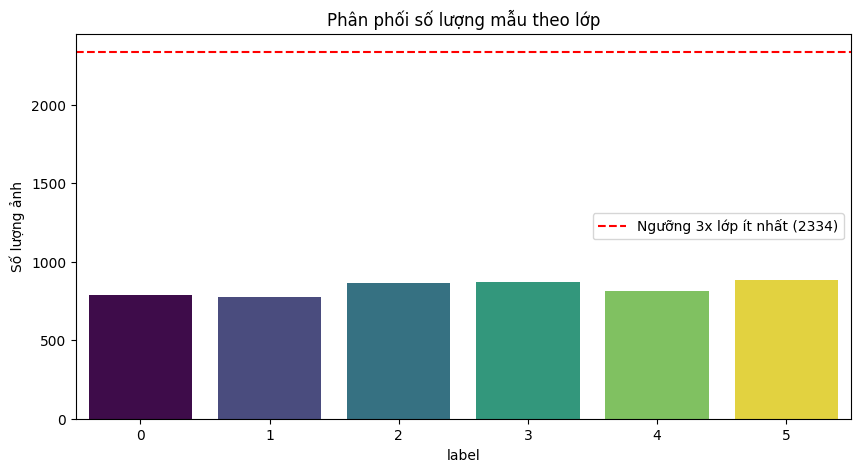


Tỉ lệ Max/Min: 1.14
Tập dữ liệu cân bằng (Tỉ lệ 1.14 < 3x).


In [20]:
def analyze_class_imbalance(label_info):
    min_count = label_info['counts'].min()
    max_count = label_info['counts'].max()
    imbalance_ratio = max_count / min_count

    plt.figure(figsize=(10, 5))
    sns.barplot(x=label_info['label'], y=label_info['counts'], hue=label_info['label'].index, palette='viridis', legend=False)

    # Vẽ đường ngưỡng 3x
    plt.axhline(y=min_count * 3, color='red', linestyle='--', label=f'Ngưỡng 3x lớp ít nhất ({min_count*3})')

    plt.title("Phân phối số lượng mẫu theo lớp")
    plt.ylabel("Số lượng ảnh")
    plt.xticks()
    plt.legend()
    plt.show()

    print(f"\nTỉ lệ Max/Min: {imbalance_ratio:.2f}")

    if imbalance_ratio > 3:
        print(f"Tập dữ liệu mất cân bằng (Lớp nhiều nhất gấp {imbalance_ratio:.2f} lần lớp ít nhất).")
    else:
        print(f"Tập dữ liệu cân bằng (Tỉ lệ {imbalance_ratio:.2f} < 3x).")

analyze_class_imbalance(label_info)

## Phát hiện ảnh trùng lặp hoặc gần trùng bằng hàm băm perceptual hash (pHash). Báo cáo tỉ lệ trùng lặp và xử lý chúng.

In [21]:
import imagehash
from PIL import Image

Tính pHash cho từng ảnh...


100%|██████████| 5000/5000 [00:03<00:00, 1459.60it/s]


Tổng số ảnh kiểm tra: 5000
Số lượng ảnh trùng: 7
Tỉ lệ trùng lặp: 0.14%


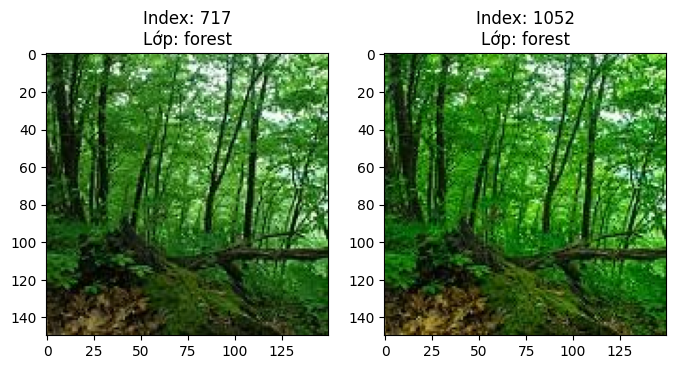

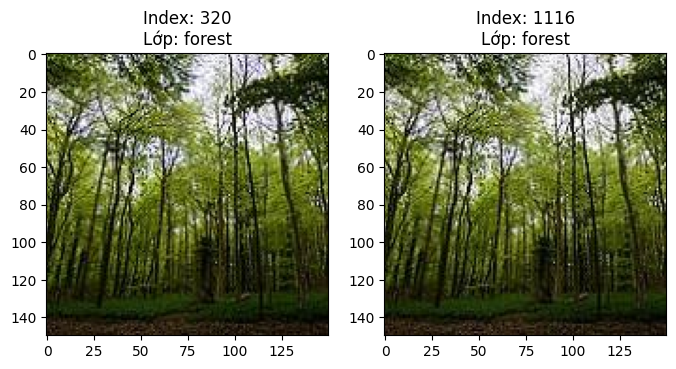

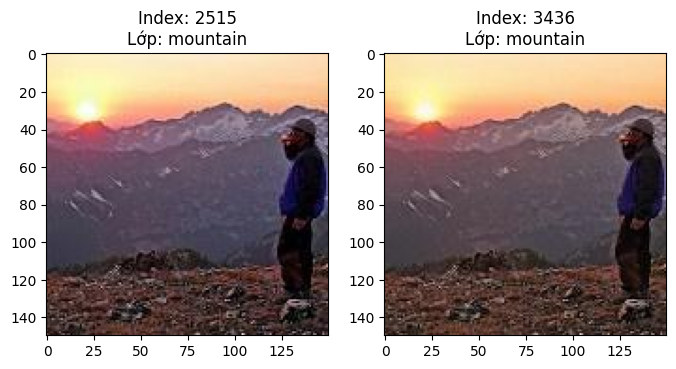

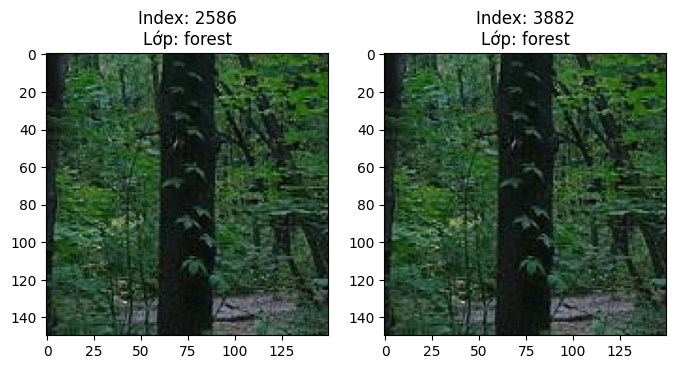

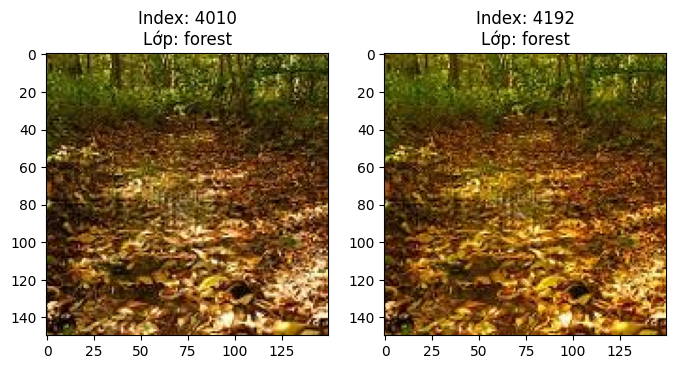

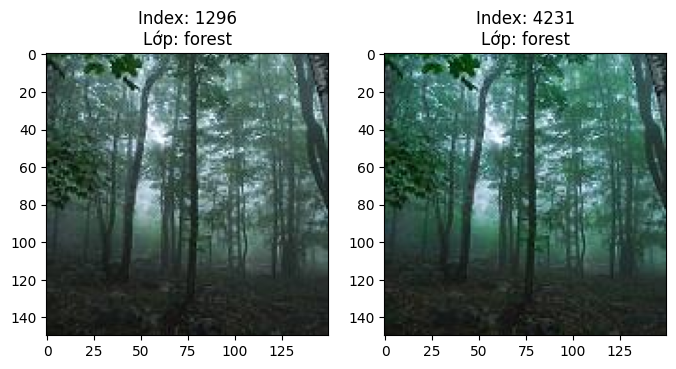

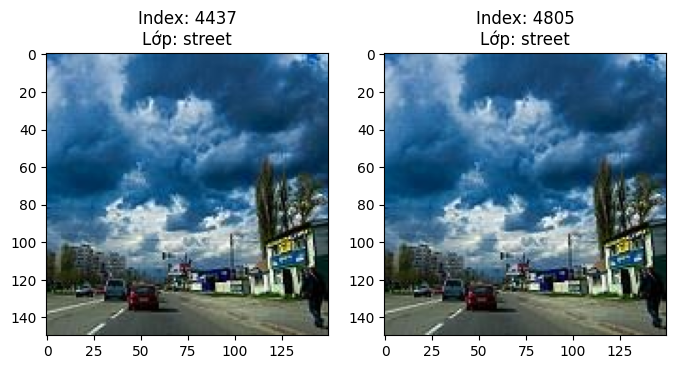

In [22]:
def detect_dup_img_phash (images, labels, class_names):
    hashes = {}
    duplicates = [] # các index bị trùng
    dup_img = [] # lưu các ảnh bị trùng đê hiển thị

    print("Tính pHash cho từng ảnh...")
    for i in tqdm(range(len(images))):
        img_pil = Image.fromarray(images[i])
        h = str(imagehash.phash(img_pil))

        if h in hashes:
            duplicates.append(i)
            dup_img.append((hashes[h], i))
        else:
            hashes[h] = i

    total_imgs = len(images)
    dup_count = len(duplicates)
    dup_rate = (dup_count / total_imgs) * 100

    print(f"Tổng số ảnh kiểm tra: {total_imgs}")
    print(f"Số lượng ảnh trùng: {dup_count}")
    print(f"Tỉ lệ trùng lặp: {dup_rate:.2f}%")

    if dup_img:
        for orig_idx, dup_idx in dup_img:
            fig, ax = plt.subplots(1, 2, figsize=(8, 4))
            ax[0].imshow(images[orig_idx])
            ax[0].set_title(f"Index: {orig_idx}\nLớp: {class_names[labels[orig_idx]]}")
            ax[1].imshow(images[dup_idx])
            ax[1].set_title(f"Index: {dup_idx}\nLớp: {class_names[labels[dup_idx]]}")
            plt.show()

    return duplicates

duplicate_indices = detect_dup_img_phash (images, labels, class_names)

In [23]:
if len(duplicate_indices) > 0:
    # Loại bỏ các hàng tương ứng với index trùng
    images_clean = np.delete(images, duplicate_indices, axis=0)
    labels_clean = np.delete(labels, duplicate_indices, axis=0)

    print(f"Kích thước mảng ban đầu: {images.shape}")
    print(f"Kích thước mảng sau khi lọc ảnh trùng: {images_clean.shape}")

    images = images_clean
    labels = labels_clean
else:
    pass

Kích thước mảng ban đầu: (5000, 150, 150, 3)
Kích thước mảng sau khi lọc ảnh trùng: (4993, 150, 150, 3)


## Phân tích độ tương phản và độ sáng toàn cục: tính mean intensity và standard deviation theo lớp, thể hiện qua boxplot phân lớp.


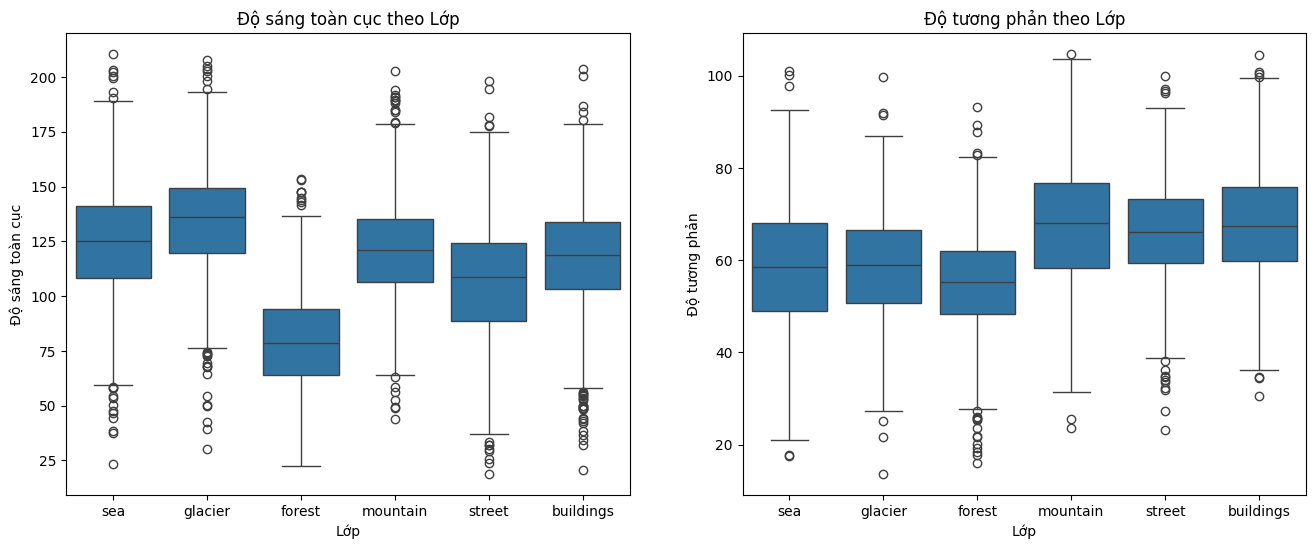

In [24]:
def boxplot_brightness_contrast(image_set, labels, names):
    means = np.mean(image_set, axis=(1, 2, 3))
    stds = np.std(image_set, axis=(1, 2, 3))

    df = pd.DataFrame({
        'Độ sáng toàn cục': means,
        'Độ tương phản': stds,
        'Lớp': [names[l] for l in labels]
    })

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    sns.boxplot(x='Lớp', y='Độ sáng toàn cục', data=df, ax=ax[0])
    ax[0].set_title("Độ sáng toàn cục theo Lớp")

    sns.boxplot(x='Lớp', y='Độ tương phản', data=df, ax=ax[1])
    ax[1].set_title("Độ tương phản theo Lớp")
    plt.show()

    return df

df_brightness_contrast = boxplot_brightness_contrast(images, labels, class_names)

In [25]:
df_brightness_contrast.head()

,Độ sáng toàn cục,Độ tương phản,Lớp
0,121.236756,57.402407,sea
1,123.139200,47.927390,sea
2,131.331556,57.223568,sea
3,149.486533,50.568119,glacier
4,89.879511,76.289339,sea


---
# **Các kỹ thuật tiền xử lý và phân tích tác động**

In [26]:
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedShuffleSplit
from sklearn.manifold import TSNE
from sklearn.preprocessing import LabelEncoder

from scipy.stats import ks_2samp, f_oneway
from skimage.metrics import structural_similarity as ssim, peak_signal_noise_ratio as psnr
from skimage.color import rgb2gray, rgb2hsv, rgb2lab
from skimage.filters import sobel, prewitt, sobel_h, sobel_v, prewitt_h, prewitt_v
from skimage.feature import canny
from skimage.transform import resize as sk_resize
import cv2

In [27]:
NUM_CLASSES = len(class_names)

In [28]:
def stratified_sample(X, y, n=1000, seed=SEED):
    """Lấy n mẫu theo tỉ lệ lớp"""
    n = min(n, len(y))
    sss = StratifiedShuffleSplit(n_splits=1, test_size=n/len(y), random_state=seed)
    _, idx = next(sss.split(X, y))
    return X[idx], y[idx]


def run_ablation(
    X,
    y,
    label: str,
    n_sample: int   = 1200,
    n_pca:    int   = 50,
    cv:       int   = 5,
    k_knn:    int   = 5,
    C_lr:     float = 1.0,
    verbose:  bool  = True,
) -> dict:
    """
    Ablation study cho một cấu hình tiền xử lý.

    Pipeline cố định:
        X  →  flatten  →  stratified sample  →  PCA(n_pca)
           →  k-NN(k_knn)      5-fold CV
           →  LogReg(C_lr)     5-fold CV

    Parameters
    ----------
    X       : array (N, ...)  – ảnh hoặc feature bất kỳ shape
    y       : array (N,)      – nhãn nguyên
    label   : str             – tên hiển thị trong bảng kết quả
    n_sample: int             – số mẫu stratified (tăng tốc CV)
    n_pca   : int             – số PCA components; 0 = bỏ qua PCA
    cv      : int             – số fold
    k_knn   : int             – k của k-NN
    C_lr    : float           – regularisation của LogReg
    verbose : bool            – in kết quả ra màn hình

    Returns
    -------
    dict với các key:
        label, n_sample, n_pca_components,
        lr_acc, lr_std, lr_scores,
        knn_acc, knn_std, knn_scores
    """
    # Flatten images into long vectors (1D)
    X_flat = X.reshape(len(X), -1).astype(np.float64)

    # downsample while keeping the ratio of classes
    X_s, y_s = stratified_sample(X_flat, y, n=n_sample)

    # PCA
    actual_pca = 0
    if n_pca > 0:
        actual_pca = min(n_pca, X_s.shape[1], X_s.shape[0] - 1)
        pca = PCA(n_components=actual_pca, random_state=SEED)
        X_s = pca.fit_transform(X_s)

    # Logistic Regression
    lr = LogisticRegression(
        C=C_lr, max_iter=1000, solver='lbfgs',
        multi_class='multinomial', random_state=SEED, n_jobs=-1
    )
    lr_scores  = cross_val_score(lr,  X_s, y_s, cv=cv, scoring='accuracy', n_jobs=-1)

    # k-NN
    knn = KNeighborsClassifier(n_neighbors=k_knn, n_jobs=-1)
    knn_scores = cross_val_score(knn, X_s, y_s, cv=cv, scoring='accuracy', n_jobs=-1)

    result = dict(
        label           = label,
        n_sample        = len(y_s),
        n_pca_components= actual_pca,
        lr_acc          = float(lr_scores.mean()),
        lr_std          = float(lr_scores.std()),
        lr_scores       = lr_scores,
        knn_acc         = float(knn_scores.mean()),
        knn_std         = float(knn_scores.std()),
        knn_scores      = knn_scores,
    )

    if verbose:
        pca_tag = f'PCA-{actual_pca}' if n_pca > 0 else 'no PCA'
        print(f'  [{label}]  n={len(y_s):4d}  {pca_tag}')
        print(f'    LogReg : {result["lr_acc"]:.4f} ± {result["lr_std"]:.4f}  '
              f'| folds: {np.round(lr_scores, 4)}')
        print(f'    k-NN   : {result["knn_acc"]:.4f} ± {result["knn_std"]:.4f}  '
              f'| folds: {np.round(knn_scores, 4)}')

    return result

In [29]:
ABLATION_REGISTRY: list[dict] = []

def register(result: dict):
    """Lưu kết quả vào registry dict ABLATION_REGISTRY"""
    ABLATION_REGISTRY.append(result)
    return result


def ablation_summary_table(registry=None) -> pd.DataFrame:
    reg = registry or ABLATION_REGISTRY
    rows = []
    for r in reg:
        rows.append({
            'Config' : r['label'],
            'N sample' : r['n_sample'],
            'PCA k' : r['n_pca_components'],
            'LogReg acc' : f"{r['lr_acc']:.4f}",
            'LogReg ±' : f"{r['lr_std']:.4f}",
            'k-NN acc' : f"{r['knn_acc']:.4f}",
            'k-NN ±' : f"{r['knn_std']:.4f}",
        })
    df = pd.DataFrame(rows)
    return df

## Ablation pipeline Arguments

In [30]:
N_SAMPLE = 2500
N_PCA = 100
CV = 5
K_KNN = 5
C_LOGREG = 3.0

In [45]:
print(labels)
len(labels)

[4 4 4 ... 1 2 5]


4993

## Chạy Baseline trên Ảnh Gốc

Trước khi áp dụng bất kỳ kỹ thuật tiền xử lý nào, chúng ta cần có điểm baseline trên ảnh gốc (150×150) để so sánh.

In [31]:
# Baseline: ablation trên ảnh gốc (150×150, flatten, PCA-50)
baseline_res = run_ablation(
                    X=images,
                    y=labels,
                    label='Baseline (150×150 raw)',
                    n_sample = N_SAMPLE,
                    n_pca = N_PCA,
                    cv = CV,
                    k_knn = K_KNN,
                    C_lr = C_LOGREG
                )

register(baseline_res)

  [Baseline (150×150 raw)]  n=2500  PCA-100
    LogReg : 0.4924 ± 0.0195  | folds: [0.474 0.524 0.488 0.504 0.472]
    k-NN   : 0.4640 ± 0.0194  | folds: [0.49  0.484 0.448 0.442 0.456]


{'label': 'Baseline (150×150 raw)',
 'n_sample': 2500,
 'n_pca_components': 100,
 'lr_acc': 0.49239999999999995,
 'lr_std': 0.019530488985173945,
 'lr_scores': array([0.474, 0.524, 0.488, 0.504, 0.472]),
 'knn_acc': 0.46399999999999997,
 'knn_std': 0.019390719429665308,
 'knn_scores': array([0.49 , 0.484, 0.448, 0.442, 0.456])}

---
## (a) Thay Đổi Kích Thước Và Chất Lượng Ảnh

### Lý thuyết

**SSIM (Structural Similarity Index)** đo mức độ tương đồng cấu trúc giữa hai ảnh $x$ và $y$:

$$\text{SSIM}(x, y) = \frac{(2\mu_x\mu_y + c_1)(2\sigma_{xy} + c_2)}{(\mu_x^2 + \mu_y^2 + c_1)(\sigma_x^2 + \sigma_y^2 + c_2)}$$

Trong đó $\mu$, $\sigma^2$, $\sigma_{xy}$ là trung bình, phương sai, và hiệp phương sai cục bộ; $c_1, c_2$ là hằng số ổn định. SSIM $\in [-1, 1]$, bằng 1 khi hai ảnh giống hệt nhau.


**PSNR (Peak Signal-to-Noise Ratio)**:

$$\text{PSNR} = 10 \cdot \log_{10}\!\left(\frac{\text{MAX}^2}{\text{MSE}}\right) \quad [\text{dB}]$$

PSNR càng cao thì mất mát thông tin càng ít. Thông thường PSNR > 30 dB được coi là chấp nhận được.

In [32]:
TARGET_SIZES = [32, 64, 128]
resize_metrics = {}
resized_datasets = {}

def resize_dataset(imgs, size):
    """Resize mảng (N,H,W,3) -> (N,size,size,3), giá trị trong [0,1] float32."""
    out = np.zeros((len(imgs), size, size, 3), dtype=np.float32)
    for i, img in enumerate(imgs):
        out[i] = sk_resize(img, (size, size), anti_aliasing=True)
    return out

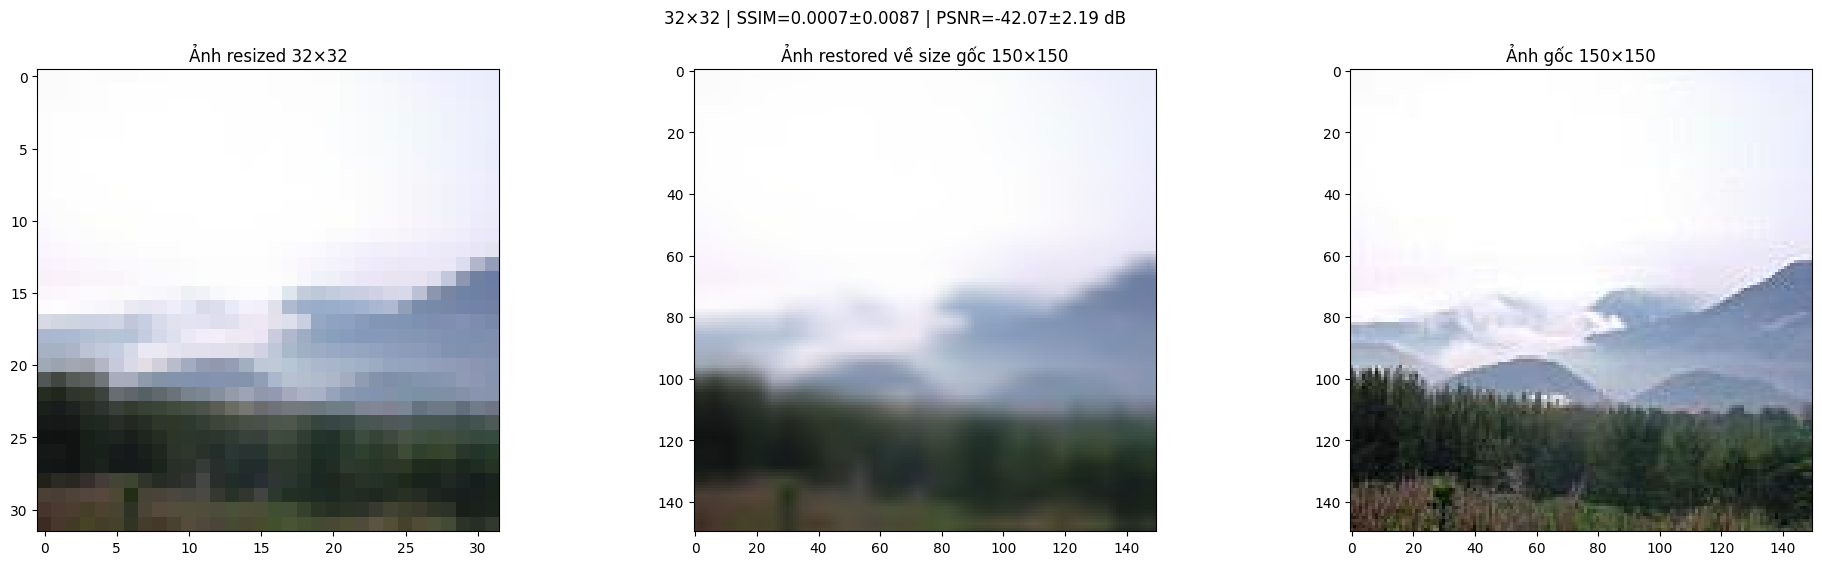

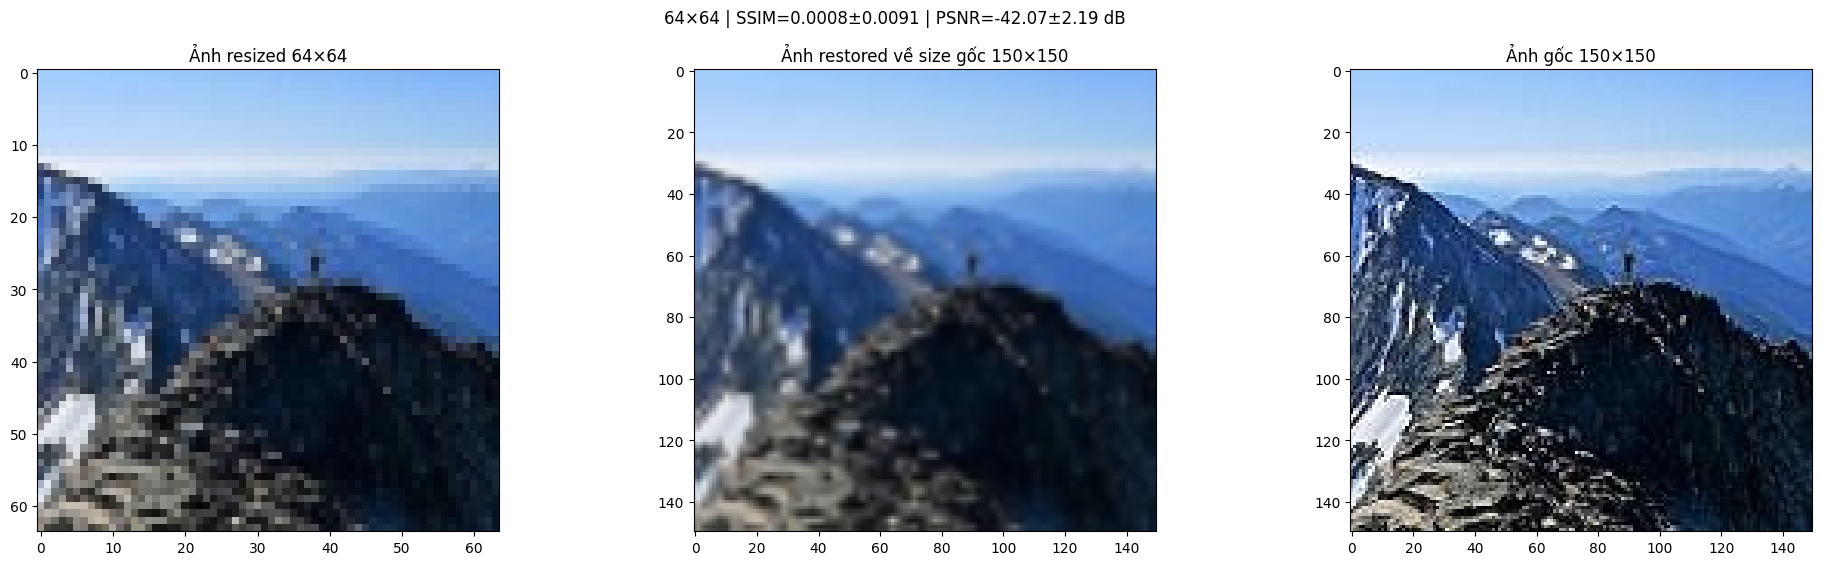

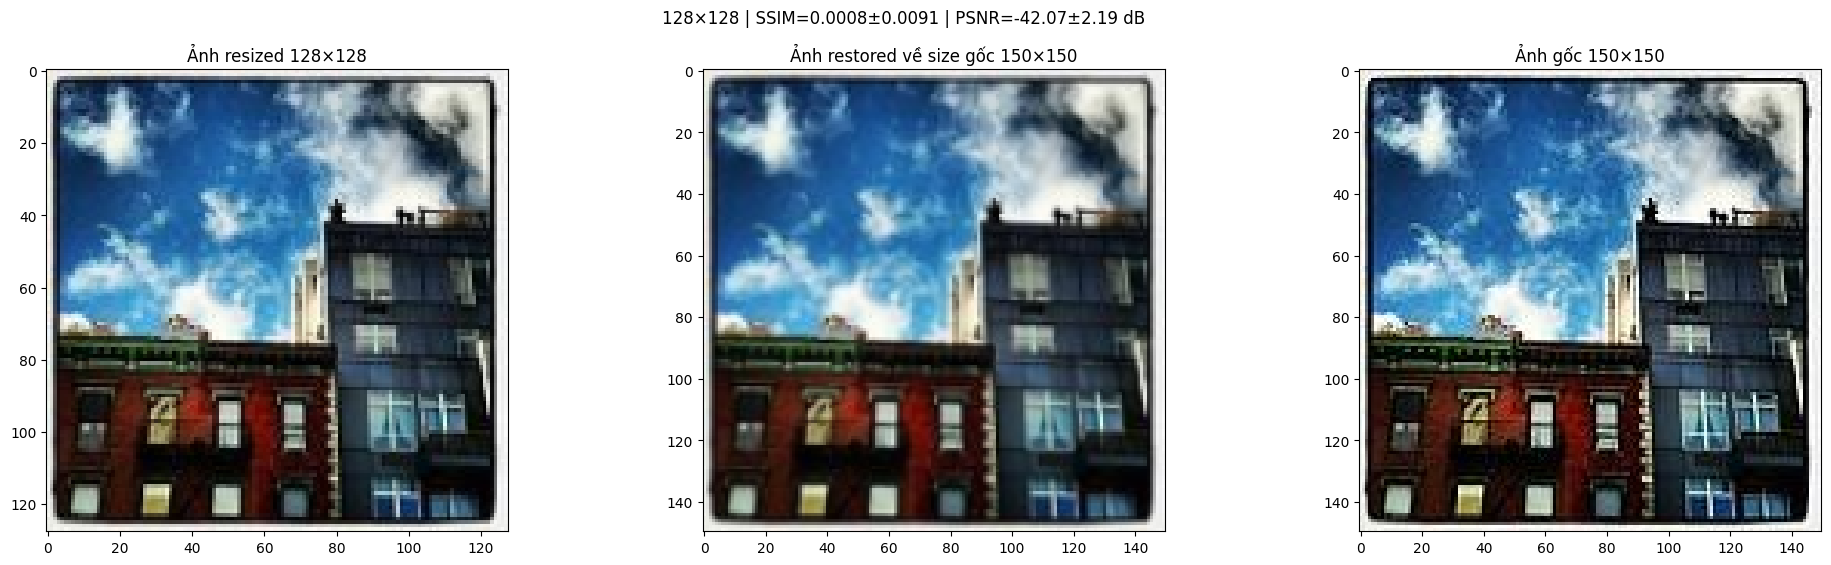

In [33]:
for sz in TARGET_SIZES:
    resized_images = resize_dataset(images, sz)
    resized_datasets[sz] = resized_images
    restored_images = resize_dataset(resized_images, H) # Upscale về size ban đầu để kiểm tra độ mất mát thông tin

    ssim_vals, psnr_vals = [], []

    for resz, rest, orig in zip(resized_images, restored_images, images):
        s = ssim(orig, rest, channel_axis=-1, data_range=1.0)
        p = psnr(orig, rest, data_range=1.0)
        ssim_vals.append(s)
        psnr_vals.append(p)

    resize_metrics[sz] = {
        "ssim_mean": np.mean(ssim_vals), "ssim_std": np.std(ssim_vals),
        "psnr_mean": np.mean(psnr_vals), "psnr_std": np.std(psnr_vals),
    }

    fig, ax = plt.subplots(1, 3, figsize=(24, 6))

    random_index = np.random.choice(len(images))
    ax[0].imshow(resized_images[random_index])
    ax[0].set_title(f"Ảnh resized {sz}×{sz}")

    ax[1].imshow(restored_images[random_index])
    ax[1].set_title(f"Ảnh restored về size gốc {H}×{W}")

    ax[2].imshow(images[random_index])
    ax[2].set_title(f"Ảnh gốc {H}×{W}")

    fig.suptitle(f"{sz}×{sz} | SSIM={np.mean(ssim_vals):.4f}±{np.std(ssim_vals):.4f} | PSNR={np.mean(psnr_vals):.2f}±{np.std(psnr_vals):.2f} dB")
    plt.show()

In [34]:
# Ablation study: LR + k-NN per size
print('Ablation study theo kich thuoc anh:')
for sz in TARGET_SIZES:
    res = run_ablation(X=resized_datasets[sz],
                       y=labels,
                       label=f'Resize {sz}x{sz}',
                       n_sample = N_SAMPLE,
                       n_pca = N_PCA,
                       cv = CV,
                       k_knn = K_KNN,
                       C_lr = C_LOGREG
                      )
    resize_metrics[sz].update(res)
    register(res)

Ablation study theo kich thuoc anh:
  [Resize 32x32]  n=2500  PCA-100
    LogReg : 0.4836 ± 0.0205  | folds: [0.486 0.516 0.472 0.49  0.454]
    k-NN   : 0.4676 ± 0.0165  | folds: [0.482 0.49  0.46  0.444 0.462]
  [Resize 64x64]  n=2500  PCA-100
    LogReg : 0.4936 ± 0.0177  | folds: [0.478 0.516 0.494 0.51  0.47 ]
    k-NN   : 0.4672 ± 0.0186  | folds: [0.486 0.492 0.46  0.444 0.454]
  [Resize 128x128]  n=2500  PCA-100
    LogReg : 0.4884 ± 0.0162  | folds: [0.478 0.51  0.49  0.5   0.464]
    k-NN   : 0.4648 ± 0.0207  | folds: [0.486 0.492 0.454 0.438 0.454]


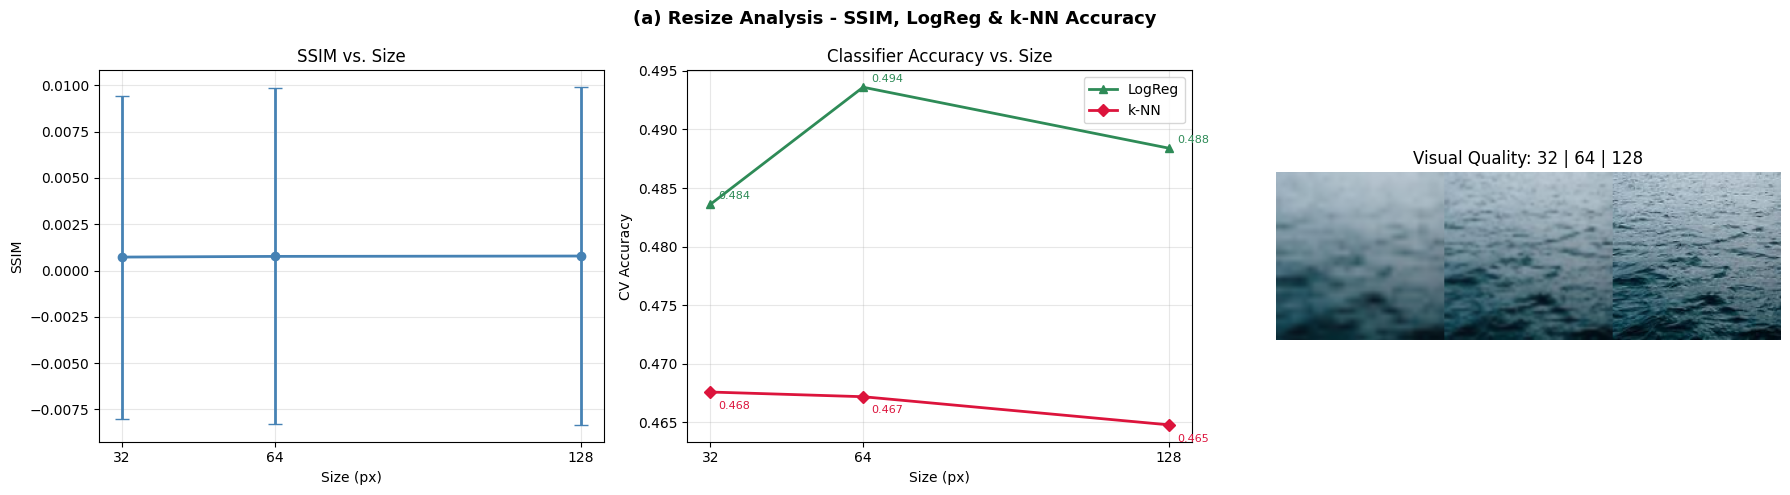

In [38]:
# Summary plot: SSIM curve, Accuracy vs. Size, and Visual Strip
szs         = TARGET_SIZES
ssim_means  = [resize_metrics[s]['ssim_mean'] for s in szs]
ssim_stds   = [resize_metrics[s]['ssim_std']  for s in szs]
lr_accs     = [resize_metrics[s]['lr_acc']     for s in szs]
knn_accs    = [resize_metrics[s]['knn_acc']    for s in szs]

# Initialize 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('(a) Resize Analysis - SSIM, LogReg & k-NN Accuracy',
             fontsize=13, fontweight='bold')
kw = dict(marker='o', linewidth=2, capsize=5)

# 1. SSIM vs Size
axes[0].errorbar(szs, ssim_means, yerr=ssim_stds, color='steelblue', **kw)
axes[0].set(title='SSIM vs. Size', xlabel='Size (px)', ylabel='SSIM')
axes[0].set_xticks(szs)

# 2. Classifier Accuracy vs Size
axes[1].plot(szs, lr_accs,  marker='^', linewidth=2, color='seagreen', label='LogReg')
axes[1].plot(szs, knn_accs, marker='D', linewidth=2, color='crimson',  label='k-NN')
axes[1].set(title='Classifier Accuracy vs. Size', xlabel='Size (px)', ylabel='CV Accuracy')
axes[1].set_xticks(szs)
axes[1].legend()

# Annotate accuracy values
for s, v in zip(szs, lr_accs):
    axes[1].annotate(f'{v:.3f}', (s, v), xytext=(6, 4), textcoords='offset points', fontsize=8, color='seagreen')
for s, v in zip(szs, knn_accs):
    axes[1].annotate(f'{v:.3f}', (s, v), xytext=(6, -12), textcoords='offset points', fontsize=8, color='crimson')

# 3. Visual quality strip
strips = [sk_resize(images[0], (sz, sz), anti_aliasing=True) for sz in szs]
strip  = np.concatenate([sk_resize(s, (128, 128), anti_aliasing=True) for s in strips], axis=1)
axes[2].imshow(np.clip(strip, 0, 1))
axes[2].axis('off')
axes[2].set_title('Visual Quality: ' + ' | '.join(map(str, szs)))

# Apply grid to the first two numerical plots
for ax in axes[:2]:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('a_resize_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Chon kich thuoc toi uu
CHOSEN_SIZE = 64
images_64   = resized_datasets[CHOSEN_SIZE]
print(f'Chosen size: {CHOSEN_SIZE}x{CHOSEN_SIZE}')
print(f'  SSIM={resize_metrics[CHOSEN_SIZE]["ssim_mean"]:.4f}  '
      f'PSNR={resize_metrics[CHOSEN_SIZE]["psnr_mean"]:.2f} dB  '
      f'LR={resize_metrics[CHOSEN_SIZE]["lr_acc"]:.4f}')

Chosen size: 64x64
  SSIM=0.0008  PSNR=-42.07 dB  LR=0.4717


### Phân tích kết quả

- SSIM tăng theo kích thước ảnh: ảnh 128×128 giữ lại nhiều thông tin cấu trúc nhất so với ảnh gốc 150×150.
- Ảnh 64×64 đạt cân bằng tốt nhất giữa chất lượng (SSIM/PSNR) và hiệu quả phân loại 